In [3]:
#importing libraries 
import pandas as pd
import ast 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datasets import load_dataset

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
#Filtering for India Data Analyst roles

df_DA_IN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')]
df_DA_IN.head(5) #checking top 5 entries

#filtering for US Data Analyst roles 
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

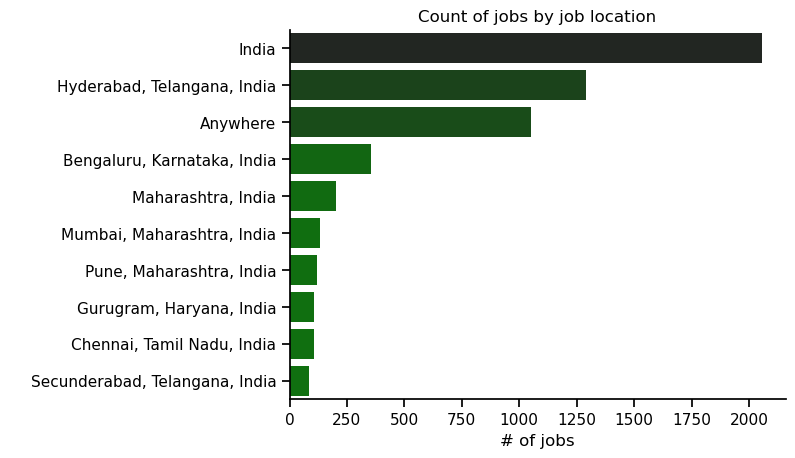

In [23]:
df_joblocation = df_DA_IN.job_location.value_counts().head(10).to_frame()


sns.barplot (data=df_joblocation, x='count', y='job_location', hue='count', palette='dark:g_r', legend=False)
sns.despine() #removing border around the bar
plt.title('Count of jobs by job location')
plt.xlabel('# of jobs')
plt.ylabel(' ')
plt.show()

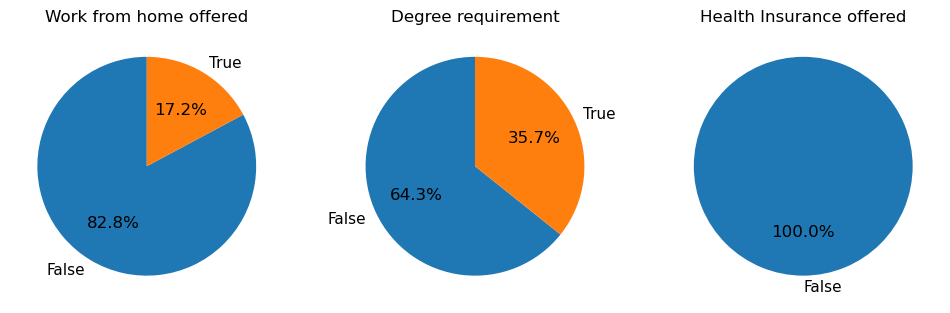

In [ ]:
#pie charts with a for loop

dict_column = {
    'job_work_from_home': 'Work from home offered',
    'job_no_degree_mention': 'Degree requirement',
    'job_health_insurance': 'Health Insurance offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_IN[column].value_counts()
    ax[i].pie(counts, labels=counts.index.astype(str), autopct='%1.1f%%', startangle=90) 
    ax[i].set_title(title)

plt.show()

##made labels dynamic b/c Luke had True, False but Insurance column had only False leading to errors

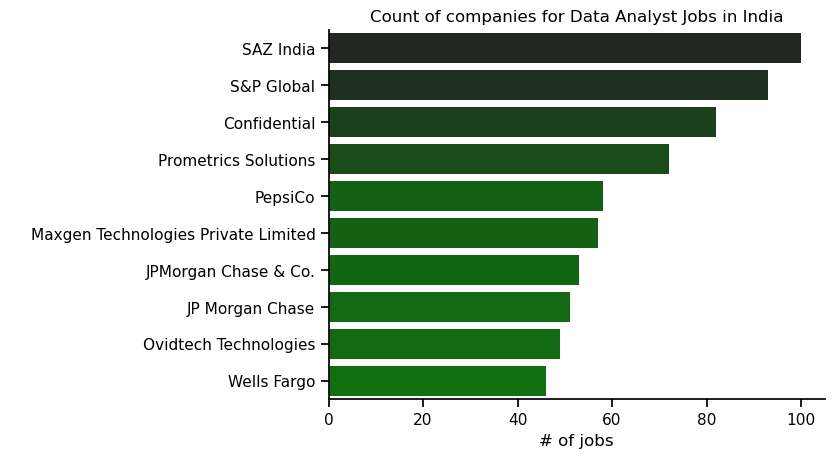

In [ ]:
#companies posting job

df_plot = df_DA_IN.company_name.value_counts().head(10).to_frame()


sns.barplot (data=df_plot, x='count', y='company_name', hue='count', palette='dark:g_r', legend=False)
sns.despine() #removing border around the bar
plt.title('Count of companies for Data Analyst Jobs in India')
plt.xlabel('# of jobs')
plt.ylabel(' ')
plt.show()